# Implementation for K-Nearest Neighbours algorithm with an IRIS Dataset
# 

# Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Reading Dataset
irisdata =pd.read_csv('../input/iris/Iris.csv')

In [3]:
#view shape of data
irisdata.shape

(150, 6)

In [4]:
irisdata['Species']

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: Species, Length: 150, dtype: object

In [5]:
#view first 5 Row from data
irisdata.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
irisdata.head(2)#view first 2 row from dataset

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa


In [7]:
#check if there is any inconsistency in the dataset
#as we see there are no null values in the dataset, so the data can be processed
irisdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


# drop unneeded columns

In [8]:
#drop unneeded columns Id columns is unnecessary

irisdata.drop('Id' ,axis=1 ,inplace=True)
#axis =1 it mean specifies that it should be column wise
#inplace=True means the changes should be reflected into the dataframe
irisdata.head(2)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa


# Data Analysis With IRIS

**Show relationship between the sepal length and width**

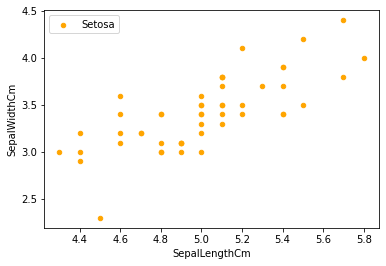

In [9]:
#choose one kind from Species (iris-setosa) to drow graph between the sepal length and width
fig = irisdata[irisdata.Species=='Iris-setosa'].plot(kind='scatter' , x='SepalLengthCm' ,
                                                     y='SepalWidthCm' , color='orange' , label='Setosa')

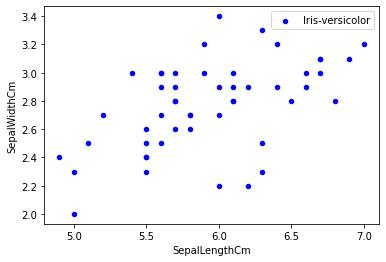

In [10]:
#choose another kind from Species (Iris-versicolor) to drow graph between the sepal length and width
fig = irisdata[irisdata.Species=='Iris-versicolor'].plot(kind='scatter' , x='SepalLengthCm' ,
                                                        y='SepalWidthCm' , color = 'blue' , label='Iris-versicolor' )

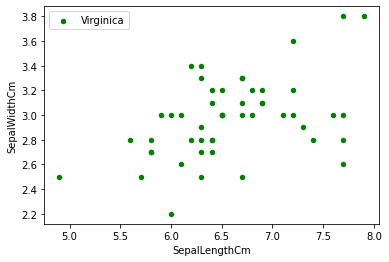

In [11]:
#choose another kind from Species (Iris-virginica) to drow graph between the sepal length and width
fig = irisdata[irisdata.Species == 'Iris-virginica'].plot(kind='scatter' , x='SepalLengthCm' , y='SepalWidthCm' , 
                                                         color = 'green' , label='Virginica')

**Show relationship between the sepal length and width in Iris-setosa , Iris-versicolor , and Iris-virginica **

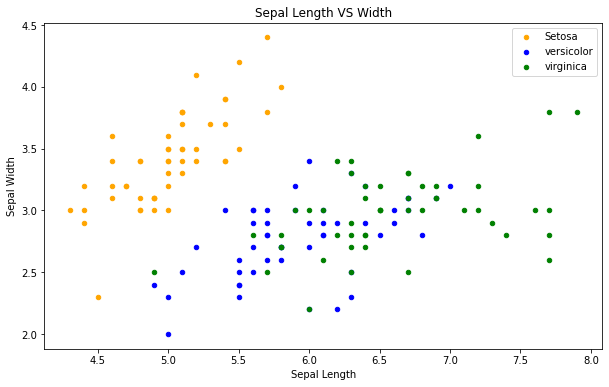

In [12]:
fig_sepal = irisdata[irisdata.Species=='Iris-setosa'].plot(kind='scatter',x='SepalLengthCm',y='SepalWidthCm',color='orange', label='Setosa')
irisdata[irisdata.Species=='Iris-versicolor'].plot(kind='scatter',x='SepalLengthCm',y='SepalWidthCm',color='blue', label='versicolor',ax=fig_sepal)
irisdata[irisdata.Species=='Iris-virginica'].plot(kind='scatter',x='SepalLengthCm',y='SepalWidthCm',color='green', label='virginica', ax=fig_sepal)
fig_sepal.set_xlabel("Sepal Length")
fig_sepal.set_ylabel("Sepal Width")
fig_sepal.set_title("Sepal Length VS Width")
fig_sepal=plt.gcf() 
fig_sepal.set_size_inches(10,6)#size of gragh is 10 * 6
plt.show()# view graph
#ax=fig to show all (3) graphs in one graph

**check relationship between the petal length and width.**

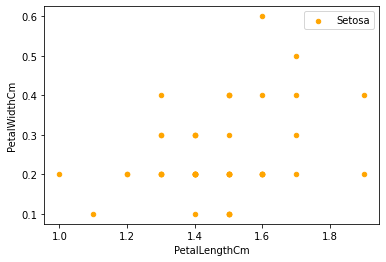

In [13]:
#graph for Species [setosa]
fig_petal = irisdata[irisdata.Species == 'Iris-setosa'].plot.scatter(x='PetalLengthCm' , y='PetalWidthCm', 
                                                                    color='orange' , label='Setosa' )

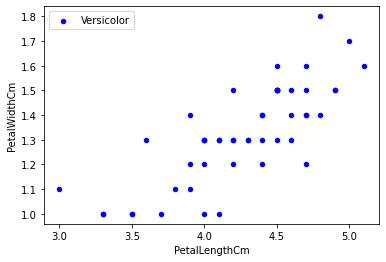

In [14]:
#graph for Species [Iris-versicolor]
fig_petal=irisdata[irisdata.Species=='Iris-versicolor'].plot.scatter(x='PetalLengthCm', y='PetalWidthCm',
                                                                        color='blue' , label='Versicolor')

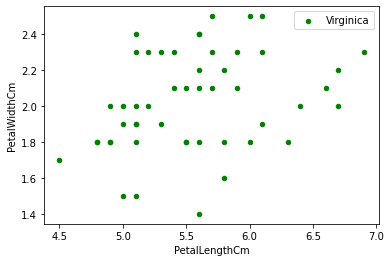

In [15]:
#graph for Species [Iris-virginica]
fig_petal = irisdata[irisdata.Species=='Iris-virginica'].plot.scatter(x='PetalLengthCm', y='PetalWidthCm',
                                                                     color='green' , label='Virginica')

**Show relationship between the petal length and width in Iris-setosa , Iris-versicolor , and Iris-virginica **

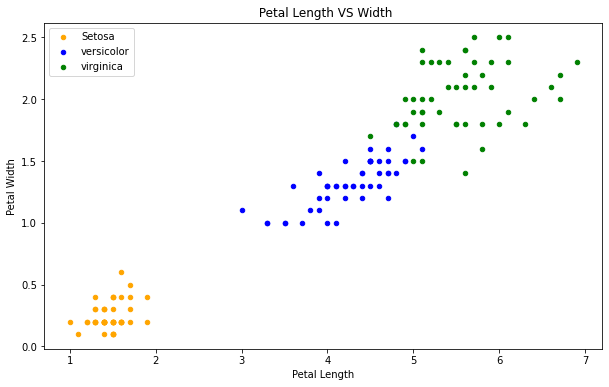

In [16]:
fig_petal = irisdata[irisdata.Species=='Iris-setosa'].plot.scatter(x='PetalLengthCm',y='PetalWidthCm',color='orange', label='Setosa')
irisdata[irisdata.Species=='Iris-versicolor'].plot.scatter(x='PetalLengthCm',y='PetalWidthCm',color='blue', label='versicolor',ax=fig_petal)
irisdata[irisdata.Species=='Iris-virginica'].plot.scatter(x='PetalLengthCm',y='PetalWidthCm',color='green', label='virginica', ax=fig_petal)
fig_petal.set_xlabel("Petal Length")
fig_petal.set_ylabel("Petal Width")
fig_petal.set_title(" Petal Length VS Width")
fig_petal=plt.gcf()
fig_petal.set_size_inches(10,6)
plt.show()

**As we can see that the Petal Features are giving a better cluster division compared to the Sepal features. This is an indication that the Petals can help in better and accurate Predictions over the Sepal.**

# Splitting The Data into Training And Testing Dataset

In [17]:
from sklearn.model_selection import train_test_split #importting to split the dataset
train ,test = train_test_split(irisdata , test_size=0.3 , random_state=0) 
#splitting into 70% train and 30% test data as test_siza=0.3


In [18]:
irisdata.shape

(150, 5)

In [19]:
train.shape

(105, 5)

In [20]:
test.shape

(45, 5)

In [21]:
#Training data features
x_train = train[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]
#output of training data
y_train = train.Species
#test data features
x_test = test[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]
#
y_test = test.Species

**View values of x_train , x_test , y_train and y_test**

In [22]:
x_train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
60,5.0,2.0,3.5,1.0
116,6.5,3.0,5.5,1.8
144,6.7,3.3,5.7,2.5
119,6.0,2.2,5.0,1.5
108,6.7,2.5,5.8,1.8


In [23]:
x_test.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
114,5.8,2.8,5.1,2.4
62,6.0,2.2,4.0,1.0
33,5.5,4.2,1.4,0.2
107,7.3,2.9,6.3,1.8
7,5.0,3.4,1.5,0.2


In [24]:
y_train.head()

60     Iris-versicolor
116     Iris-virginica
144     Iris-virginica
119     Iris-virginica
108     Iris-virginica
Name: Species, dtype: object

In [25]:
y_test.head()

114     Iris-virginica
62     Iris-versicolor
33         Iris-setosa
107     Iris-virginica
7          Iris-setosa
Name: Species, dtype: object

# K-Nearest Neighbours

In [26]:
from sklearn.neighbors import KNeighborsClassifier 
KNC_Model = KNeighborsClassifier(n_neighbors=3)
KNC_Model.fit(x_train , y_train)
prediction = KNC_Model.predict(x_test)

In [27]:
from sklearn import metrics
Accuracy = metrics.accuracy_score(prediction , y_test)
print('The Accuracy Of KNN Is :: ' , Accuracy)

The Accuracy Of KNN Is ::  0.9777777777777777


**check the accuracy for various values of n for K-Nearest nerighbours**

**Accuracy was constant with n_neighbors from 1 to 11**

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  


([<matplotlib.axis.XTick at 0x7fafdb5b3ed0>,
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

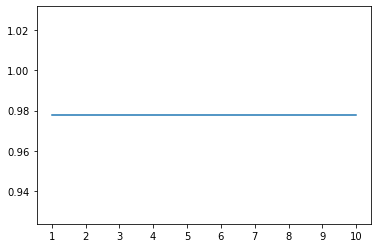

In [28]:
a_index=list(range(1,11))
a=pd.Series()
x=list(range(1,11))
for i in list(range(1,11)):
    KNC_Model=KNeighborsClassifier(n_neighbors=i) 
    KNC_Model.fit(x_train,y_train)
    prediction=KNC_Model.predict(x_test)
    a=a.append(pd.Series(metrics.accuracy_score(prediction,y_test)))
plt.plot(a_index, a)
plt.xticks(x)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  


([<matplotlib.axis.XTick at 0x7fafdb52dfd0>,
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

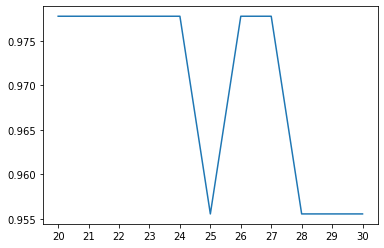

In [29]:
a_index=list(range(20,31))
a=pd.Series()
x=list(range(20,31))
for i in list(range(20,31)):
    KNC_Model=KNeighborsClassifier(n_neighbors=i) 
    KNC_Model.fit(x_train,y_train)
    prediction=KNC_Model.predict(x_test)
    a=a.append(pd.Series(metrics.accuracy_score(prediction,y_test)))
plt.plot(a_index, a)
plt.xticks(x)

**when k_neighbors was High the Accuracy changes**